<a href="https://colab.research.google.com/github/DaminikaDz/Data_Ranking_Training_Dynamics/blob/main/src/colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
!wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
!tar -xzf imagenette2-160.tgz

--2026-04-26 13:18:17--  https://s3.amazonaws.com/fast-ai-imageclas/imagenette2-160.tgz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.207.239, 16.15.188.39, 16.15.253.125, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.207.239|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99003388 (94M) [application/x-tar]
Saving to: ‘imagenette2-160.tgz’

imagenette2-160.tgz 100%[===================>]  94.42M  12.2MB/s    in 9.5s    

2026-04-26 13:18:27 (9.96 MB/s) - ‘imagenette2-160.tgz’ saved [99003388/99003388]



In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch.nn.functional as F

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [ ]:
!pip install torch torchvision tqdm scikit-learn pandas pillow -q

In [4]:
model = torch.hub.load("facebookresearch/dinov2", "dinov2_vitl14")
model = model.to(device)
model.eval()

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitl14_pretrain.pth


100%|██████████| 1.13G/1.13G [00:10<00:00, 111MB/s]


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-23): 24 x NestedTensorBlock(
      (norm1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=1024, out_features=3072, bias=True)
        (proj): Linear(in_features=1024, out_features=1024, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=1024, out_features=4096, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=4096, out_features=1024, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((1024,), eps=1e-06, element

In [5]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
train_ds = datasets.ImageFolder("imagenette2-160/train", transform=transform)
val_ds = datasets.ImageFolder("imagenette2-160/val", transform=transform)

print(len(train_ds), len(val_ds))

9469 3925


In [7]:
train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [8]:
def extract_embeddings(loader, model, device):
    all_embeddings = []
    all_labels = []
    all_paths = []

    with torch.inference_mode():
        for images, labels in tqdm(loader):
            images = images.to(device, non_blocking=True)

            emb = model(images)
            emb = F.normalize(emb, dim=1)

            all_embeddings.append(emb.cpu().numpy())
            all_labels.extend(labels.numpy())

    embeddings = np.vstack(all_embeddings)
    labels = np.array(all_labels)

    return embeddings, labels

In [9]:
train_embeddings, train_labels = extract_embeddings(train_loader, model, device)
val_embeddings, val_labels = extract_embeddings(val_loader, model, device)

print(train_embeddings.shape)
print(val_embeddings.shape)

100%|██████████| 62/62 [03:13<00:00,  3.13s/it]

(9469, 1024)
(3925, 1024)


In [10]:
!git clone https://github.com/facebookresearch/ssl-data-curation.git
%cd ssl-data-curation

Cloning into 'ssl-data-curation'...
remote: Enumerating objects: 35, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 35 (delta 3), reused 0 (delta 0), pack-reused 20 (from 1)
Receiving objects: 100% (35/35), 1.97 MiB | 35.36 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/ssl-data-curation


In [ ]:
!pip install -r requirements.txt

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.6/811.6 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 96.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [11]:
from src.clusters import HierarchicalCluster
from src import (
    hierarchical_kmeans_gpu as hkmg,
    hierarchical_sampling as hs
)

In [12]:
data=torch.tensor(train_embeddings, device="cuda", dtype=torch.float32)

In [13]:
np.Inf = np.inf

In [14]:
clusters = hkmg.hierarchical_kmeans_with_resampling(
  data=torch.tensor(data, device="cuda", dtype=torch.float32),
  n_clusters=[1000, 300, 100],
  n_levels=3,
  sample_sizes=[5, 3, 2],
  verbose=True,
)

cl = HierarchicalCluster.from_dict(clusters)
sampled_indices = hs.hierarchical_sampling(cl, target_size=2000)

/tmp/ipykernel_4787/434840230.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data=torch.tensor(data, device="cuda", dtype=torch.float32),


Hierarchical sampling from clusters: 100%|██████████| 100/100 [00:00<00:00, 2828.71it/s]


In [15]:
subset_labels = train_labels[sampled_indices]

pd.Series(subset_labels).value_counts().sort_index()

,count
0,221
1,158
2,179
3,162
4,475
5,170
6,128
7,161
8,158
9,188


In [16]:
from torch.utils.data import Subset
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

In [17]:
hkm_subset_ds = Subset(train_ds, sampled_indices)

In [18]:
import random

random.seed(42)
random_indices = random.sample(range(len(train_ds)), k=2000)

random_subset_ds = Subset(train_ds, random_indices)

random_labels = train_labels[random_indices]
print("Random subset class distribution:")
print(pd.Series(random_labels).value_counts().sort_index())

Random subset class distribution:
0    198
1    210
2    212
3    185
4    218
5    209
6    190
7    202
8    182
9    194
Name: count, dtype: int64


In [19]:
batch_size = 64

full_train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
hkm_train_loader = DataLoader(hkm_subset_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
random_train_loader = DataLoader(random_subset_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
num_classes = len(train_ds.classes)

def create_resnet50(frozen=True):
    weights = ResNet50_Weights.IMAGENET1K_V2
    model = resnet50(weights=weights)

    if frozen:
        for p in model.parameters():
            p.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model.to(device)

In [21]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in tqdm(loader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.inference_mode():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, correct / total

In [22]:
def run_experiment(name, train_loader, frozen=True, epochs=5):
    model = create_resnet50(frozen=frozen)
    criterion = nn.CrossEntropyLoss()

    if frozen:
        optimizer = torch.optim.AdamW(model.fc.parameters(), lr=1e-3)
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

    history = []

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        print(
            f"{name} | epoch {epoch+1}/{epochs} | "
            f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f}"
        )

        history.append({
            "experiment": name,
            "epoch": epoch + 1,
            "frozen": frozen,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

    return pd.DataFrame(history)

In [25]:
results = []

results.append(run_experiment("full_frozen", full_train_loader, frozen=True, epochs=5))
results.append(run_experiment("hkm2000_frozen", hkm_train_loader, frozen=True, epochs=5))

results.append(run_experiment("full_unfrozen", full_train_loader, frozen=False, epochs=5))
results.append(run_experiment("hkm2000_unfrozen", hkm_train_loader, frozen=False, epochs=10))

results.append(run_experiment("random2000_frozen",   random_train_loader, frozen=True,  epochs=5))
results.append(run_experiment("random2000_unfrozen", random_train_loader, frozen=False, epochs=5))

results_df = pd.concat(results, ignore_index=True)

results_df

100%|██████████| 148/148 [00:38<00:00,  3.89it/s]


full_frozen | epoch 1/5 | train_acc=0.9295 | val_acc=0.9768


100%|██████████| 148/148 [00:35<00:00,  4.22it/s]


full_frozen | epoch 2/5 | train_acc=0.9822 | val_acc=0.9817


100%|██████████| 148/148 [00:36<00:00,  4.05it/s]


...

100%|██████████| 32/32 [00:21<00:00,  1.49it/s]


random2000_unfrozen | epoch 4/5 | train_acc=0.9150 | val_acc=0.9093


100%|██████████| 32/32 [00:21<00:00,  1.50it/s]


random2000_unfrozen | epoch 5/5 | train_acc=0.9475 | val_acc=0.9315


,experiment,epoch,frozen,train_loss,train_acc,val_loss,val_acc
0,full_frozen,1,True,0.513096,0.929454,0.151993,0.976815
1,full_frozen,2,True,0.108485,0.982152,0.090905,0.981656
2,full_frozen,3,True,0.067352,0.987644,0.075335,0.984204
3,full_frozen,4,True,0.051724,0.989334,0.064026,0.984713
4,full_frozen,5,True,0.039877,0.991340,0.056195,0.986497
5,hkm2000_frozen,1,True,1.444031,0.608500,0.946321,0.921019
6,hkm2000_frozen,2,True,0.586190,0.921500,0.505380,0.955924
7,hkm2000_frozen,3,True,0.347467,0.956000,0.365476,0.960764
8,hkm2000_frozen,4,True,0.258420,0.963000,0.275292,0.971465
9,hkm2000_frozen,5,True,0.198114,0.975000,0.228519,0.974268


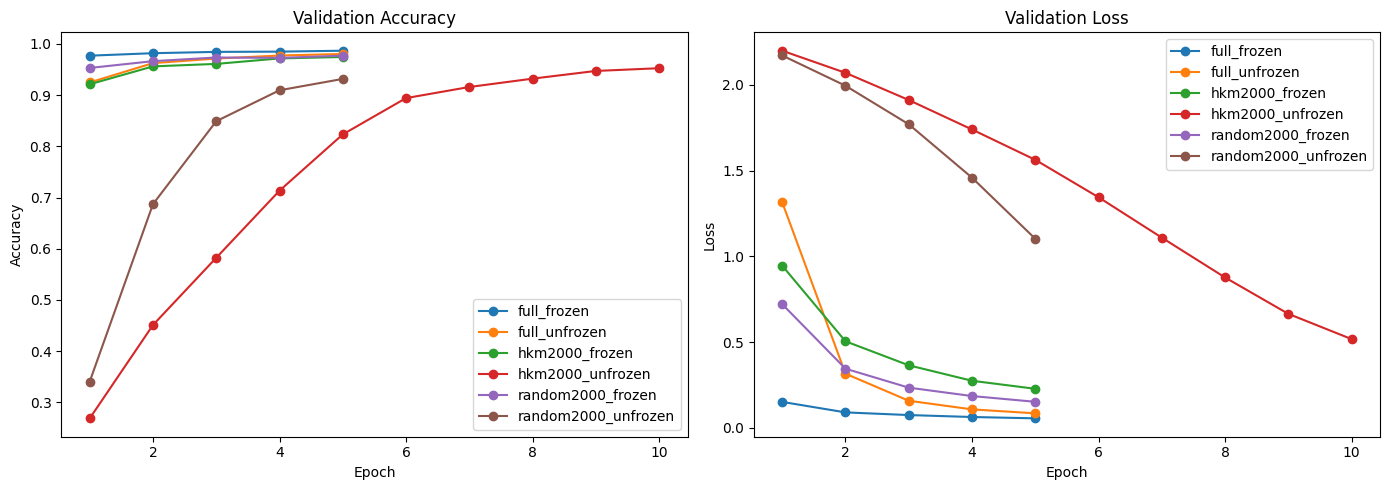

In [27]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exp_name, group in results_df.groupby("experiment"):
    axes[0].plot(group["epoch"], group["val_acc"], marker="o", label=exp_name)
    axes[1].plot(group["epoch"], group["val_loss"], marker="o", label=exp_name)

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

In [30]:
#tabela porownawcza hkm us random
summary = (
    results_df
    .groupby("experiment")
    .agg(
        best_val_acc=("val_acc", "max"),
        final_val_acc=("val_acc", "last"),
        dataset_size=("experiment", lambda x: 2000 if "2000" in x.iloc[0] else len(train_ds))
    )
    .reset_index()
)

summary["vs_random_gain"] = summary.apply(
    lambda row: (
        row["best_val_acc"]
        - summary.loc[
            summary["experiment"] == row["experiment"].replace("hkm", "random"),
            "best_val_acc"
        ].values[0]
    ) if "hkm" in row["experiment"] else None,
    axis=1
)

print(summary.to_markdown(index=False))

| experiment          |   best_val_acc |   final_val_acc |   dataset_size |   vs_random_gain |
|:--------------------|---------------:|----------------:|---------------:|-----------------:|
| full_frozen         |       0.986497 |        0.986497 |           9469 |     nan          |
| full_unfrozen       |       0.980127 |        0.980127 |           9469 |     nan          |
| hkm2000_frozen      |       0.974268 |        0.974268 |           2000 |      -0.00254777 |
| hkm2000_unfrozen    |       0.952357 |        0.952357 |           2000 |       0.0208917  |
| random2000_frozen   |       0.976815 |        0.976815 |           2000 |     nan          |
| random2000_unfrozen |       0.931465 |        0.931465 |           2000 |     nan          |


In [31]:
# Czas treningu
efficiency = summary.copy()
efficiency["dataset_size"] = efficiency["experiment"].map({
    "full_frozen": len(train_ds),
    "hkm2000_frozen": 2000,
    "full_unfrozen": len(train_ds),
    "hkm2000_unfrozen": 2000,
})
efficiency["acc_per_1k_samples"] = efficiency["best_val_acc"] / (efficiency["dataset_size"] / 1000)
print(efficiency[["experiment", "dataset_size", "best_val_acc", "acc_per_1k_samples"]])

            experiment  dataset_size  best_val_acc  acc_per_1k_samples
0          full_frozen        9469.0      0.986497            0.104182
1        full_unfrozen        9469.0      0.980127            0.103509
2       hkm2000_frozen        2000.0      0.974268            0.487134
3     hkm2000_unfrozen        2000.0      0.952357            0.476178
4    random2000_frozen           NaN      0.976815                 NaN
5  random2000_unfrozen           NaN      0.931465                 NaN


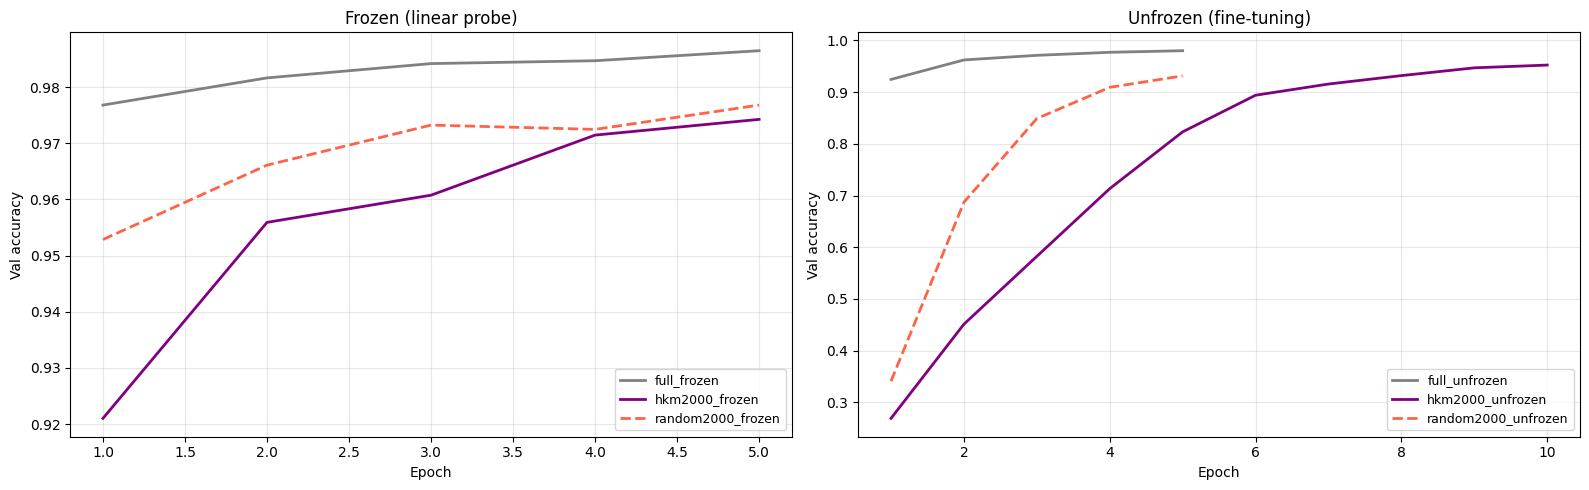

In [32]:
#wykres
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

STYLE = {
    "full_frozen":         dict(color="gray",   linestyle="-",  linewidth=2),
    "hkm2000_frozen":      dict(color="purple", linestyle="-",  linewidth=2),
    "random2000_frozen":   dict(color="tomato", linestyle="--", linewidth=2),
    "full_unfrozen":       dict(color="gray",   linestyle="-",  linewidth=2),
    "hkm2000_unfrozen":    dict(color="purple", linestyle="-",  linewidth=2),
    "random2000_unfrozen": dict(color="tomato", linestyle="--", linewidth=2),
}

for frozen, ax, title in [
    (True,  axes[0], "Frozen (linear probe)"),
    (False, axes[1], "Unfrozen (fine-tuning)"),
]:
    subset = results_df[results_df["frozen"] == frozen]
    for name, grp in subset.groupby("experiment"):
        ax.plot(grp["epoch"], grp["val_acc"], label=name, **STYLE.get(name, {}))
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Val accuracy")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

In [37]:

level1_centroids   = clusters[0]['centroids'].cpu().numpy()  # (1000, 1024)
level1_assignments = clusters[0]['assignment']               # (9469,)

def dist_to_centroid_fast(embeddings, assignments, centroids):
    assigned_centroids = centroids[assignments]              # (9469, 1024)
    diffs = embeddings - assigned_centroids
    return np.linalg.norm(diffs, axis=1)                    # (9469,)

all_dists = dist_to_centroid_fast(train_embeddings, level1_assignments, level1_centroids)

hkm_dists  = all_dists[sampled_indices]
other_mask = np.ones(len(train_embeddings), dtype=bool)
other_mask[sampled_indices] = False
other_dists = all_dists[other_mask]

print(f"HKM subset  — średnia odległość od centroidu: {hkm_dists.mean():.4f} ± {hkm_dists.std():.4f}")
print(f"Odrzucone   — średnia odległość od centroidu: {other_dists.mean():.4f} ± {other_dists.std():.4f}")

HKM subset  — średnia odległość od centroidu: 0.4204 ± 0.2842
Odrzucone   — średnia odległość od centroidu: 0.5739 ± 0.1515


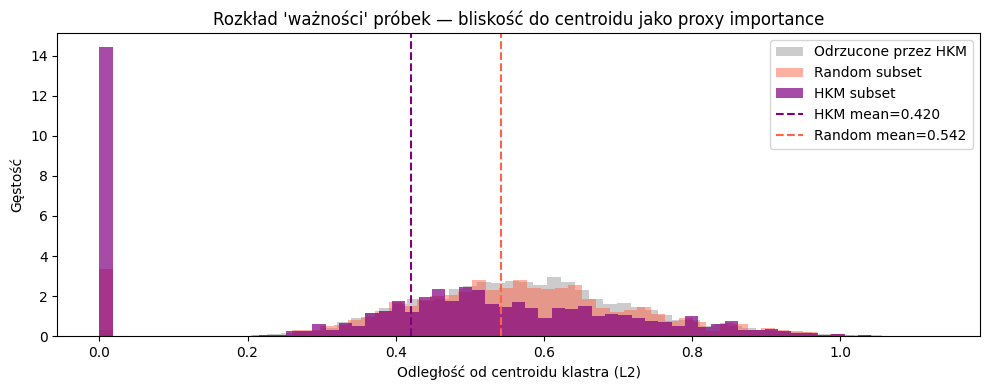

In [38]:
random_dists = all_dists[random_indices]

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(other_dists,  bins=60, alpha=0.4, color="gray",   density=True, label="Odrzucone przez HKM")
ax.hist(random_dists, bins=60, alpha=0.5, color="tomato", density=True, label="Random subset")
ax.hist(hkm_dists,    bins=60, alpha=0.7, color="purple", density=True, label="HKM subset")

ax.axvline(hkm_dists.mean(),    color="purple", linestyle="--", linewidth=1.5, label=f"HKM mean={hkm_dists.mean():.3f}")
ax.axvline(random_dists.mean(), color="tomato", linestyle="--", linewidth=1.5, label=f"Random mean={random_dists.mean():.3f}")

ax.set_xlabel("Odległość od centroidu klastra (L2)")
ax.set_ylabel("Gęstość")
ax.set_title("Rozkład 'ważności' próbek — bliskość do centroidu jako proxy importance")
ax.legend()
plt.tight_layout()
plt.savefig("importance_distribution.png", dpi=150)
plt.show()

In [39]:
importance_all    = 1.0 / (all_dists + 1e-8)
importance_hkm    = importance_all[sampled_indices]
importance_random = importance_all[random_indices]

summary_importance = pd.DataFrame({
    "subset":       ["HKM 2000",           "Random 2000"],
    "mean_importance": [importance_hkm.mean(), importance_random.mean()],
    "median_importance": [np.median(importance_hkm), np.median(importance_random)],
    "std_importance":  [importance_hkm.std(),  importance_random.std()],
})
print(summary_importance.to_markdown(index=False))

| subset      |   mean_importance |   median_importance |   std_importance |
|:------------|------------------:|--------------------:|-----------------:|
| HKM 2000    |          2.59e+07 |             2.10402 |      4.38086e+07 |
| Random 2000 |          6.2e+06  |             1.79369 |      2.41156e+07 |


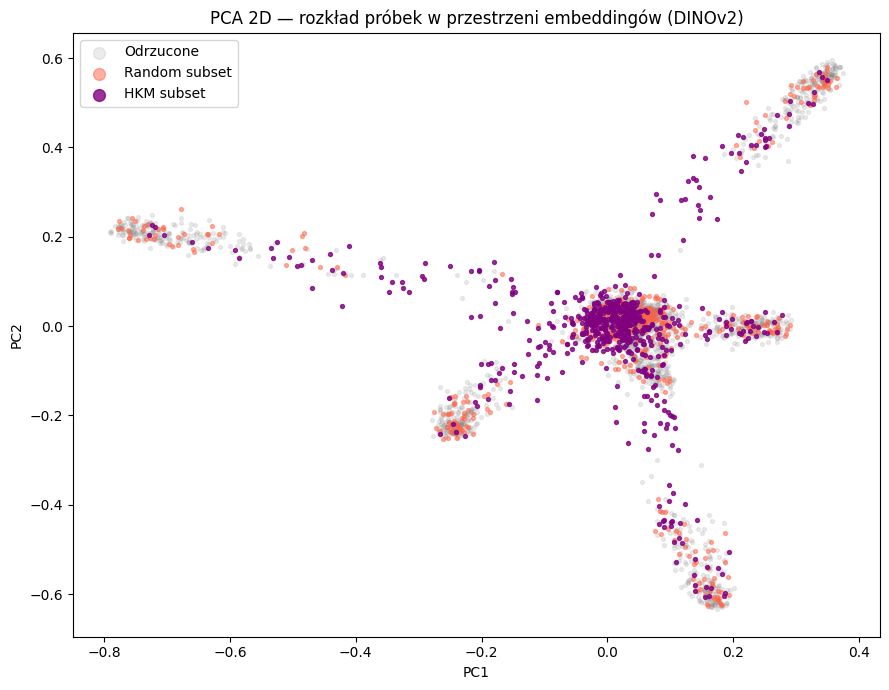

In [40]:
from sklearn.decomposition import PCA

n_vis = 3000
vis_idx = np.random.choice(len(train_embeddings), n_vis, replace=False)

pca = PCA(n_components=2, random_state=42)
emb_2d = pca.fit_transform(train_embeddings[vis_idx])

# Etykiety: 0=odrzucone, 1=random, 2=HKM
labels_vis = np.zeros(n_vis, dtype=int)
vis_set    = set(vis_idx.tolist())
hkm_set    = set(sampled_indices)
rand_set   = set(random_indices)

for k, idx in enumerate(vis_idx):
    if idx in hkm_set:
        labels_vis[k] = 2
    elif idx in rand_set:
        labels_vis[k] = 1

fig, ax = plt.subplots(figsize=(9, 7))
colors = {0: ("gray", 0.15, "Odrzucone"),
          1: ("tomato", 0.5,  "Random subset"),
          2: ("purple", 0.8,  "HKM subset")}

for lbl, (color, alpha, name) in colors.items():
    mask = labels_vis == lbl
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=color, alpha=alpha, s=8, label=name, rasterized=True)

ax.set_title("PCA 2D — rozkład próbek w przestrzeni embeddingów (DINOv2)")
ax.legend(markerscale=3)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.tight_layout()
plt.savefig("pca_subsets.png", dpi=150)
plt.show()

In [44]:
sampled_indices = np.array(sampled_indices)
random_indices  = np.array(random_indices)
hkm_set  = set(sampled_indices.tolist())
rand_set = set(random_indices.tolist())
n        = len(train_embeddings)

# Dla każdej próbki: do jakiego klastra należy na każdym poziomie
l1_asgn = clusters[0]['assignment']  # (9469,) → klaster spośród 1000
l2_asgn = clusters[1]['assignment']  # (9469,) → klaster spośród 300
l3_asgn = clusters[2]['assignment']  # (9469,) → klaster spośród 100

# Rozmiar klastra na każdym poziomie (ile próbek w tym samym klastrze)
def cluster_sizes(assignments):
    unique, counts = np.unique(assignments, return_counts=True)
    size_map = dict(zip(unique.tolist(), counts.tolist()))
    return np.array([size_map[a] for a in assignments])

l1_sizes = cluster_sizes(l1_asgn)  # im mniejszy = rzadszy = "cenniejszy"
l2_sizes = cluster_sizes(l2_asgn)
l3_sizes = cluster_sizes(l3_asgn)

print(f"Średni rozmiar klastra L1: {l1_sizes.mean():.1f} próbek")
print(f"Średni rozmiar klastra L2: {l2_sizes.mean():.1f} próbek")
print(f"Średni rozmiar klastra L3: {l3_sizes.mean():.1f} próbek")

Średni rozmiar klastra L1: 130.5 próbek
Średni rozmiar klastra L2: 12.9 próbek
Średni rozmiar klastra L3: 14.9 próbek


In [46]:
# Mapowanie próbka → L1 → L2 → L3
l1_asgn = clusters[0]['assignment']  # (9469,) → indeks klastra L1

# clusters[1]['assignment'] ma shape (1000,) — dla każdego centroidu L1, jego klaster L2
l1_to_l2 = clusters[1]['assignment']  # (1000,)
l1_to_l3 = clusters[2]['assignment']  # (300,) — dla każdego centroidu L2, jego klaster L3

# Mapuj każdą próbkę przez łańcuch
l2_asgn = l1_to_l2[l1_asgn]          # (9469,) — klaster L2 każdej próbki
l3_asgn = l1_to_l3[l2_asgn]          # (9469,) — klaster L3 każdej próbki

print(f"l1_asgn: {l1_asgn.shape}, unikalne: {len(np.unique(l1_asgn))}")
print(f"l2_asgn: {l2_asgn.shape}, unikalne: {len(np.unique(l2_asgn))}")
print(f"l3_asgn: {l3_asgn.shape}, unikalne: {len(np.unique(l3_asgn))}")

l1_asgn: (9469,), unikalne: 1000
l2_asgn: (9469,), unikalne: 300
l3_asgn: (9469,), unikalne: 100


In [48]:
# Mapowanie próbka → L1 → L2 → L3
l1_asgn = clusters[0]['assignment']
l1_to_l2 = clusters[1]['assignment']  # (1000,)
l1_to_l3 = clusters[2]['assignment']  # (300,)

l2_asgn = l1_to_l2[l1_asgn]          # (9469,)
l3_asgn = l1_to_l3[l2_asgn]          # (9469,)

print(f"l1_asgn: {l1_asgn.shape}, unikalne: {len(np.unique(l1_asgn))}")
print(f"l2_asgn: {l2_asgn.shape}, unikalne: {len(np.unique(l2_asgn))}")
print(f"l3_asgn: {l3_asgn.shape}, unikalne: {len(np.unique(l3_asgn))}")

# Rozmiary klastrów — PO mapowaniu, per próbka (9469,)
def cluster_sizes(assignments):
    unique, counts = np.unique(assignments, return_counts=True)
    size_map = dict(zip(unique.tolist(), counts.tolist()))
    return np.array([size_map[a] for a in assignments])

l1_sizes = cluster_sizes(l1_asgn)  # (9469,)
l2_sizes = cluster_sizes(l2_asgn)  # (9469,)
l3_sizes = cluster_sizes(l3_asgn)  # (9469,)

print(f"\nŚredni rozmiar klastra L1: {l1_sizes.mean():.1f}")
print(f"Średni rozmiar klastra L2: {l2_sizes.mean():.1f}")
print(f"Średni rozmiar klastra L3: {l3_sizes.mean():.1f}")

# Importance score
def norm01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

rarity_l3    = norm01(1.0 / l3_sizes)
rarity_l2    = norm01(1.0 / l2_sizes)
proximity_l1 = norm01(1.0 / (all_dists + 1e-8))

importance_score = 0.5 * rarity_l3 + 0.3 * rarity_l2 + 0.2 * proximity_l1

ranking = np.argsort(-importance_score)
rank_of_sample = np.empty(n, dtype=int)
rank_of_sample[ranking] = np.arange(n)

print(f"\nTop-10 próbek wg importance score:")
for i, idx in enumerate(ranking[:10]):
    print(f"  rank {i:3d} | idx={idx:5d} | score={importance_score[idx]:.4f} "
          f"| L3_klaster={l3_asgn[idx]:3d} (size={l3_sizes[idx]:3d}) "
          f"| HKM={'TAK' if idx in hkm_set else '   '}")

l1_asgn: (9469,), unikalne: 1000
l2_asgn: (9469,), unikalne: 300
l3_asgn: (9469,), unikalne: 100

Średni rozmiar klastra L1: 130.5
Średni rozmiar klastra L2: 408.7
Średni rozmiar klastra L3: 857.1

Top-10 próbek wg importance score:
  rank   0 | idx=    8 | score=1.0000 | L3_klaster= 35 (size=  1) | HKM=TAK
  rank   1 | idx= 9190 | score=1.0000 | L3_klaster= 32 (size=  1) | HKM=TAK
  rank   2 | idx= 8973 | score=1.0000 | L3_klaster= 37 (size=  1) | HKM=TAK
  rank   3 | idx= 2661 | score=1.0000 | L3_klaster= 88 (size=  1) | HKM=TAK
  rank   4 | idx= 9109 | score=1.0000 | L3_klaster= 34 (size=  1) | HKM=TAK
  rank   5 | idx= 9096 | score=1.0000 | L3_klaster= 24 (size=  1) | HKM=TAK
  rank   6 | idx= 4412 | score=1.0000 | L3_klaster= 58 (size=  1) | HKM=TAK
  rank   7 | idx= 5109 | score=1.0000 | L3_klaster=  6 (size=  1) | HKM=TAK
  rank   8 | idx= 1515 | score=1.0000 | L3_klaster= 81 (size=  1) | HKM=TAK
  rank   9 | idx= 3161 | score=1.0000 | L3_klaster= 93 (size=  1) | HKM=TAK


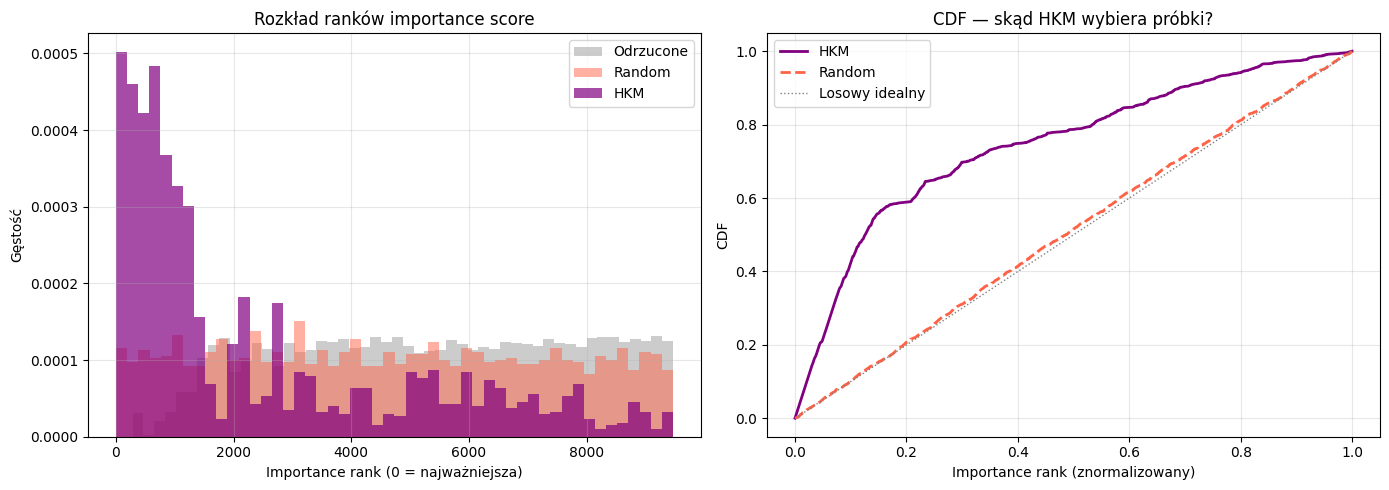

Mediana ranku HKM:    1192 / 9469
Mediana ranku random: 4608 / 9469


In [49]:
import matplotlib.pyplot as plt

hkm_ranks    = rank_of_sample[sampled_indices]
random_ranks = rank_of_sample[random_indices]
other_mask   = np.ones(n, dtype=bool)
other_mask[sampled_indices] = False
other_ranks  = rank_of_sample[other_mask]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(other_ranks,  bins=50, alpha=0.4, color="gray",   density=True, label="Odrzucone")
axes[0].hist(random_ranks, bins=50, alpha=0.5, color="tomato", density=True, label="Random")
axes[0].hist(hkm_ranks,    bins=50, alpha=0.7, color="purple", density=True, label="HKM")
axes[0].set_xlabel("Importance rank (0 = najważniejsza)")
axes[0].set_ylabel("Gęstość")
axes[0].set_title("Rozkład ranków importance score")
axes[0].legend()
axes[0].grid(alpha=0.3)

def cdf(ranks, total):
    sorted_r = np.sort(ranks)
    return sorted_r / total, np.arange(1, len(ranks)+1) / len(ranks)

x_hkm,  y_hkm  = cdf(hkm_ranks,    n)
x_rand, y_rand  = cdf(random_ranks, n)

axes[1].plot(x_hkm,  y_hkm,  color="purple", lw=2,             label="HKM")
axes[1].plot(x_rand, y_rand,  color="tomato", lw=2, ls="--",    label="Random")
axes[1].plot([0,1],  [0,1],   color="gray",   lw=1, ls=":",     label="Losowy idealny")
axes[1].set_xlabel("Importance rank (znormalizowany)")
axes[1].set_ylabel("CDF")
axes[1].set_title("CDF — skąd HKM wybiera próbki?")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("survival_importance.png", dpi=150)
plt.show()

print(f"Mediana ranku HKM:    {np.median(hkm_ranks):.0f} / {n}")
print(f"Mediana ranku random: {np.median(random_ranks):.0f} / {n}")

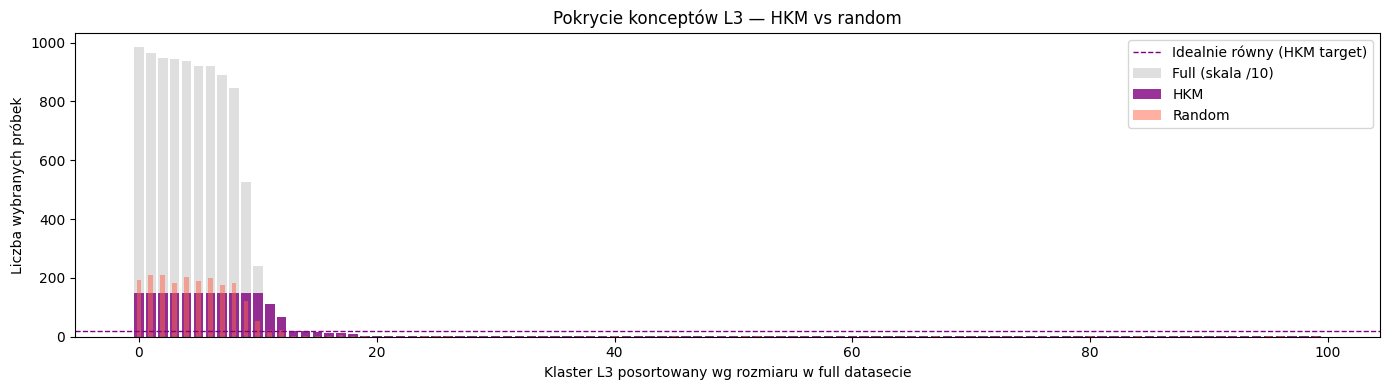

Odchylenie std pokrycia L3:
  HKM:    47.46
  Random: 56.33


In [50]:
l3_counts_hkm    = np.bincount(l3_asgn[sampled_indices],  minlength=100)
l3_counts_random = np.bincount(l3_asgn[random_indices],   minlength=100)
l3_counts_full   = np.bincount(l3_asgn,                   minlength=100)

# Posortuj wg rozmiaru klastra w full datasecie (malejąco)
order = np.argsort(-l3_counts_full)

fig, ax = plt.subplots(figsize=(14, 4))
x = np.arange(100)
ax.bar(x, l3_counts_full[order],   alpha=0.25, color="gray",   label="Full (skala /10)")
ax.bar(x, l3_counts_hkm[order],    alpha=0.8,  color="purple", label="HKM")
ax.bar(x, l3_counts_random[order], alpha=0.5,  color="tomato", label="Random", width=0.4)
ax.axhline(2000/100, color="purple", ls="--", lw=1, label="Idealnie równy (HKM target)")
ax.set_xlabel("Klaster L3 posortowany wg rozmiaru w full datasecie")
ax.set_ylabel("Liczba wybranych próbek")
ax.set_title("Pokrycie konceptów L3 — HKM vs random")
ax.legend()
plt.tight_layout()
plt.savefig("l3_coverage.png", dpi=150)
plt.show()

print(f"Odchylenie std pokrycia L3:")
print(f"  HKM:    {l3_counts_hkm.std():.2f}")
print(f"  Random: {l3_counts_random.std():.2f}")

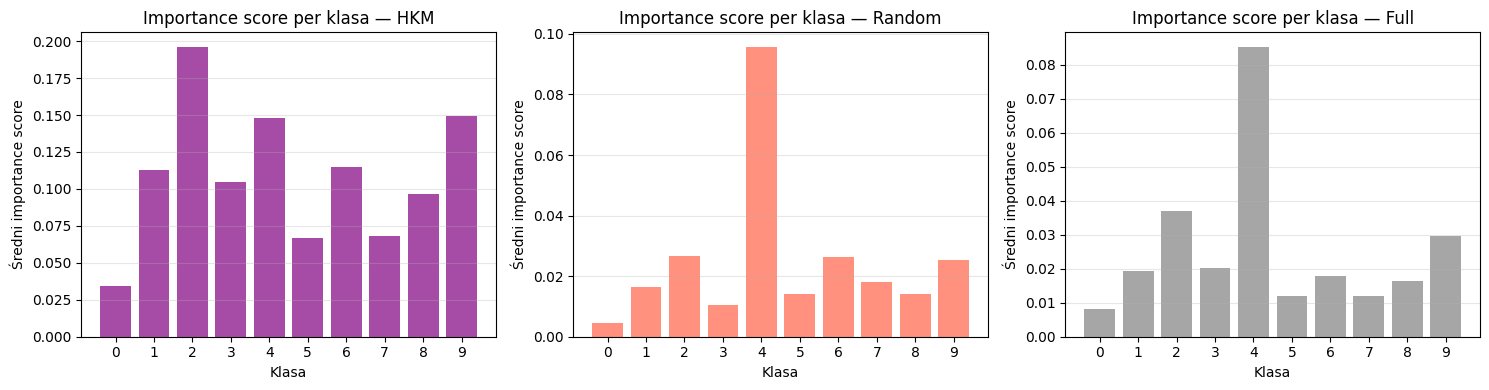

In [51]:
class_names = [str(c) for c in range(10)]  # lub train_ds.classes jeśli dostępne

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (indices, label, color) in zip(axes, [
    (sampled_indices, "HKM",    "purple"),
    (random_indices,  "Random", "tomato"),
    (np.arange(n),    "Full",   "gray"),
]):
    scores = importance_score[indices]
    labels = train_labels[indices]

    means = [scores[labels == c].mean() if (labels == c).sum() > 0 else 0
             for c in range(10)]

    ax.bar(range(10), means, color=color, alpha=0.7)
    ax.set_title(f"Importance score per klasa — {label}")
    ax.set_xlabel("Klasa")
    ax.set_ylabel("Średni importance score")
    ax.set_xticks(range(10))
    ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("importance_per_class.png", dpi=150)
plt.show()